In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$ 

In [38]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

In [54]:
# We first define the constants
p_1 = 1/np.sqrt(2)
p_2 = 0
p_3 = 0.7
N = 100
iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.

To estimate the optimal $m_1$ and $m_2$ we solve the equation

In [55]:
# step transition probabilities
def take_step(x, y, p):
    generated_prob = np.random.random()

    if generated_prob > p:
        return (x+1) % N, y 
    else:
        return x, (y+1) % N

# try all combinations lol
def find_opt_int(N, p):
    L = int(np.floor(N**(1/3)))
    minimum = 10000
    min_m1, min_m2 = -1000, -1000
    for m_1 in range(-2*L, 2*L, 1):
        for m_2 in range(-2*L, 2*L, 1):
            if m_1 == 0 and m_2 == 0:
                continue
            diophan = np.absolute(p*m_1 + (1-p)*m_2)
            if diophan < minimum:
                minimum = diophan
                min_m1 = m_1
                min_m2 = m_2
    return min_m1, min_m2

In [56]:
m_1_irrational, m_2_irrational = find_opt_int(N, p_1)

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d \in \mathbb{Z}$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

In [57]:
def compute_delta(p, m_1, m_2):
    print(p)
    all_deltas = np.zeros((number_deltas, iteration_count))

    for j in range(number_deltas):
        # we want X_0 to be sampled from the stationary distribution, so we randomly draw initial x and y
        # this is how to simulate the stationary distribution!!!
        curr_x = np.random.randint(0, N)
        curr_y = np.random.randint(0, N)
        val_sin = 0
        val_cos = 0

        for i in range(iteration_count):
            # take a step, then compute f
            curr_x, curr_y = take_step(curr_x, curr_y, p)
            val_sin += np.sin(2*np.pi*(m_1*curr_x + m_2*curr_y + 1)/N)
            val_cos += np.cos(2*np.pi*(m_1*curr_x + m_2*curr_y + 1)/N)
            # compute empirical average of f after drawing i samples
            f_sum = val_sin**2 + val_cos**2 
            all_deltas[j, i] = f_sum/(i+1)**2

    delta_n = np.sqrt(np.mean(all_deltas, axis=0))
    return delta_n

In [58]:
delta_n_1 = compute_delta(p_1, m_1_irrational, m_2_irrational) # sqrt
delta_n_3 = compute_delta(p_3, 3, -7) # rational

0.7071067811865475
0.7


Now we plot $\Delta_n$ for all the different transition probabilities

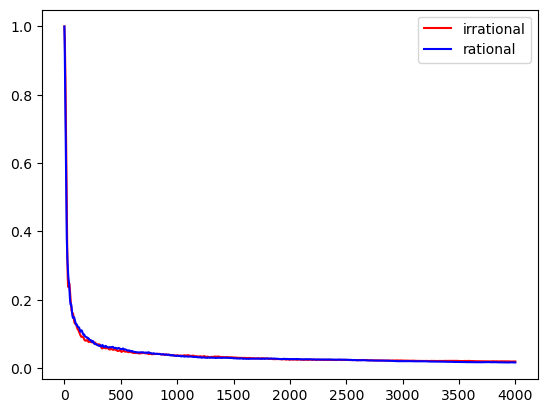

In [59]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="rational")
#plt.plot(range(iteration_count), [np.sqrt(0.2 * N**(4/3)/n) for n in range(1, iteration_count+1)], c="b", label="relaxation time")
plt.legend()

We now estimate $\tau$. We do that by finding a constant such that $\tau \geq \frac{n\Delta_n^2}{4}, \forall n \geq 1$

In [60]:
def compute_tau(delta):
    big_tau = -10

    for k in range(len(delta)):
        delta_k = delta[k]
        const = k*(delta_k**2)*1/4
        if big_tau < const:
            big_tau = const 
    return big_tau

In [61]:
tau_irrational = compute_tau(delta_n_1)
tau_irrational

np.float64(1.7892382145772077)

In [62]:
tau_rational = compute_tau(delta_n_3)
tau_rational

np.float64(1.312253271674532)

Now we plot the different $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

C:\Users\User\AppData\Local\Temp\ipykernel_12028\3988238463.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]


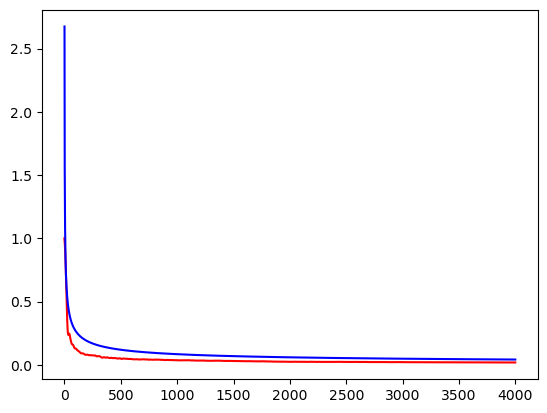

In [63]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')

C:\Users\User\AppData\Local\Temp\ipykernel_12028\3522009561.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]


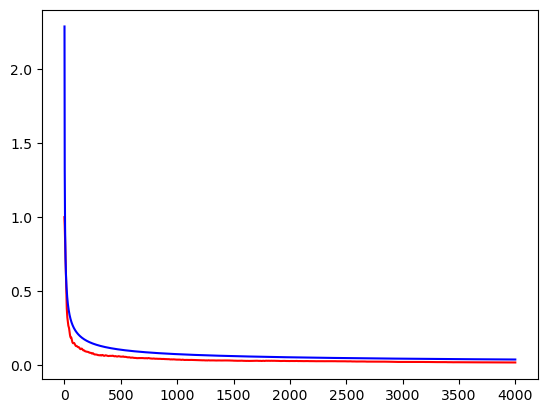

In [64]:
plt.plot(range(iteration_count), delta_n_3, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')

Compute $\tau$ with singular values. We only need to compute **one** singular value. Lanxos


We now compute the exact value of $\tau$.
We begin by computing the respective transition matrices $P_{rational}$ and $P_{irrational}$. For each matrix, respectively compute $L = I-P$ and then the second smallest singular value $\gamma$. As in the paper, we define the relaxation time of the chain by $\tau = \frac{1}{\gamma}$.

In [ ]:
### helper methods
# to go from and back to matrix indices based on a loop that goes through each element of the nodes once
def decode_index(idx):
    return idx % N, idx//N

def encode_index(x, y):
    return x + N*y

# construct the sparse matrices
def transition_positions(N, p):
    right_positions = []
    up_positions = []
    # going through every single node, and for each one adding the probability it goes right or up
    for node in range(N**2):
        x_1, y_1 = decode_index(node)
        x_2 = (x_1 + 1) % N
        y_2 = (y_1 + 1) % N

        right_node = encode_index(x_2, y_1)
        up_node = encode_index(x_1, y_2)

        right_positions.append((node, right_node))
        up_positions.append((node, up_node))

    # creating right, up, and identity sparse matrices to not kill my ram
    # data vector
    right_data = np.array([p]*len(right_positions))
    up_data = np.array([1-p]*len(up_positions))
    # data = np.concatenate((right_ps, up_ps), axis=None) 

    # separated the matrices into 3 to make debugging easier
    right_rows = np.array([k[0] for k in right_positions])
    right_cols = np.array([k[1] for k in right_positions])

    up_rows = np.array([k[0] for k in up_positions])
    up_cols = np.array([k[1] for k in up_positions])
    csr_right = csr_matrix((right_data, (right_rows, right_cols)), shape=(N**2,N**2))
    csr_up = csr_matrix((up_data, (up_rows, up_cols)), shape=(N**2,N**2))

    return csr_right, csr_up

# returns a matrix's second smallest singular value
def generator_sv(generator_matrix):
    u, s_min, vt = svds(generator_matrix, k=2, which="SM")
    abs_max = np.max(np.abs(s_min))
    return abs_max

# use helper functions above to do everything at once
def compute_tau(N, p):
    csr_right, csr_up = transition_positions(N, p)
    ones = np.ones(N**2)
    csr_identity = csr_matrix((ones, (range(N**2), range(N**2))))

    generator_matrix = csr_identity - (csr_right + csr_up)

    return 1/generator_sv(generator_matrix)

In [66]:
# computations 
irrational_tau = compute_tau(N, p_1)
rational_tau = compute_tau(N, p_3) 

In [67]:
irrational_tau

np.float64(117.14753456684554)

In [68]:
rational_tau

np.float64(135.57565743649224)